# Домашнее задание 5. Реализация воспроизводимого эксперимента

Вольхин Сергей, МФТИ, курс 501.

Все артефакты лежат в репо `git@github.com:SergeiVolkhin/ML-HW.git`, ветка `hw5`. В этом ноутбуке - сводный отчёт со ссылками, рабочий код и конфиги в репозитории.


In [ ]:
%%capture
!pip install feast psycopg psycopg_pool pandas scikit-learn -qqq
!pip install gdown tqdm -qqq
!pip install marimo -qqq
from tqdm import tqdm
import psycopg
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
!apt-get update -qq > /dev/null
!apt-get install -y yamllint > /dev/null

In [ ]:
from google.colab import userdata
import os
os.environ["tunatoken"] = userdata.get('tuna')
!curl -sSLf https://get.tuna.am | sh >/dev/null
!tuna config save-token $tunatoken

## 1. Выяснить ограничения традиционных ноутбуков Collab при разработке ML-систем по сравнению с [Marimo](https://github.com/marimo-team/marimo)


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=zIad_EXtUcVa)*



In [ ]:
print(f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте ?access_token=password, нажмите Enter")
!sleep 5 && marimo tutorial ui --port 8010 --host 0.0.0.0 --headless --token-password password & tuna http 8010 & wait

### Заметки по Marimo: что удобнее на этапе DevOps

Сравнение делал на маленьком сценарии (`notebooks/marimo_example.py` в репо): загрузка Wine, базовая статистика, пара SQL-запросов через duckdb. Что вышло.

#### 1. Воспроизводимость и hidden state

В Jupyter и Colab ячейки запускаются вручную в любом порядке. Удалил переменную из ячейки выше - в kernel она всё равно живёт, всё работает. Через 20 минут такой работы получаешь "у меня запускается", у коллеги после `Restart & Run All` падает.

В Marimo граф зависимостей между ячейками строится статически. Удалил переменную - все зависимые ячейки автоматически инвалидируются. Hidden state физически невозможен.

#### 2. Версионирование в git

`.ipynb` это JSON с base64-картинками в outputs, метаданными kernel и счётчиками `execution_count`. Каждый перезапуск ячейки меняет файл, даже если код не трогал. Diff в PR нечитаемый без `nbdime` или `jupytext`.

Marimo это `.py` с декораторами `@app.cell`. Diff = только реальные изменения кода. Code review проходит как для любого скрипта.

#### 3. CI/CD

Запуск `.ipynb` на pipeline это `papermill` или `jupyter nbconvert --to notebook --execute`. Лишние зависимости, медленный старт kernel, иногда падает на pickled outputs.

Marimo запускается как обычный python-скрипт: `python notebooks/marimo_example.py`. Импортируется как модуль, тестируется через pytest, прогоняется на любом CI runner без специальных шагов.

#### 4. Колаб-специфичные ограничения

VM эфемерная: после disconnect все `!pip install` сбрасываются. Нет lockfile, нет фиксированного образа, версии зависимостей плывут между запусками. `!pip install` зашит в ячейках и не цепляется через `pip install -r requirements.txt`. Данные обычно лежат в личном Google Drive автора - в DVC/S3 не положишь, в команду не передашь. Git тоже сбоку: коммиты делаются через GitHub-плагин, история обычно теряется.

#### 5. Интеграция с MLOps-стеком

DVC хочет в `dvc.yaml` команду вида `python src/train.py`. С `.ipynb` это `papermill notebook.ipynb out.ipynb -p ...`, лишний слой, и кэш DVC ломается на изменении output-метаданных, хотя код не менялся. Marimo `.py` ложится в `dvc.yaml` напрямую, хеш стадии стабильный.

Для `mlflow.log_artifact` `.py` это просто файл на пару килобайт, `.ipynb` - 12+ MB JSON с outputs.

#### Итого

На этапе DevOps Marimo выигрывает по всем пунктам жизненного цикла: code review, версионирование, CI/CD, упаковка артефакта. Jupyter и Colab остаются удобны для интерактивного исследования и презентаций, но в production-pipeline лучше либо конвертировать в `.py` через jupytext, либо запускать через papermill, понимая что это лишний слой.

Полный пример Marimo-ноутбука и подробное сравнение: `notebooks/marimo_example.py` и `notebooks/analysis.md` в репо.


## 2. Обеспечить воспроизводимость эксперимента, используя DVC/MLflow

* Инициализируйте Git и DVC.
* Добавьте небольшой датасет (например, Iris, Titanic или Wine).
* **Не храните данные в Git, используйте DVC**.
* Создайте пайплайн DVC минимум в две стадии.


*Ожидаемый артефакт: bash-скрипт в [ячейке](#scrollTo=HhN_l9aNrTaV)*



In [ ]:
import pandas as pd
from sklearn.datasets import load_wine

# тут грузим Wine - 3 класса, 13 фичей, 178 строк, тот же датасет что в репо
ds = load_wine(as_frame=True)
df = ds.frame.rename(columns={"target": "wine_class"})
df.to_csv("wine.csv", index=False)
print(df.shape, "записал в wine.csv")
df.head()


In [ ]:
%%bash
git init && git checkout -b master
git config --global user.email "publicemail@example.com" && git config --global user.name "publicname"
dvc config core.analytics false
dvc init -f
dvc remote add -d myremote datasets -f
dvc add energydata_complete_v1.csv && dvc commit
git add energydata_complete_v1.csv.dvc .dvc/config && git commit -m "initial_data"
dvc push
dvc exp remove -A
dvc queue remove --all
touch dvc.yaml
git checkout -b dvc-241106
dvc exp save --name first -m "241106"
dvc exp show
dvc stage add --name=preprocessing --force python script1.py
dvc stage add --name=postprocessing --force python script1.py

В репо это уже сделано, разложено по нормальным файлам:

- `data/raw/wine.csv.dvc` - DVC-указатель на сырой датасет (`wine.csv` в `.gitignore`)
- `.dvc/config` - remote `local-storage` смотрит в `./.dvc-storage/` (он закоммичен в репо, чтобы `dvc pull` работал сразу после клона)
- `dvc.yaml` - пайплайн из двух стадий:
  - `prepare` (`python src/prepare.py`): `data/raw/wine.csv` + `params.prepare` дают `data/processed/{train,test}.csv`
  - `train` (`python src/train.py`): `data/processed/` + `params.train` дают `models/model.pkl`, `confusion_matrix.png`, `metrics.json` плюс MLflow run
- `params.yaml` - гиперпараметры обеих стадий (`test_size`, `random_state`, `n_estimators`, `max_depth`)
- `dvc.lock` - зафиксированные MD5 каждой стадии для воспроизводимости

Чтобы воспроизвести:

```bash
git clone -b hw5 git@github.com:SergeiVolkhin/ML-HW.git
cd ML-HW && pip install -r requirements.txt
dvc pull        # подтягиваем wine.csv из ./.dvc-storage/
dvc repro       # пересчитываем пайплайн, метрики совпадут с metrics.json в репо
```


Граф пайплайна (`dvc dag`):

```
+-----------------------+
| data/raw/wine.csv.dvc |
+-----------------------+
            *
            *
            *
       +---------+
       | prepare |
       +---------+
            *
            *
            *
        +-------+
        | train |
        +-------+
```

Метрики (`dvc metrics show`):

| Path         | accuracy | f1_macro | precision_macro | recall_macro |
|--------------|----------|----------|-----------------|--------------|
| metrics.json | 1.0      | 1.0      | 1.0             | 1.0          |

Метрики получились "слишком хорошие", потому что Wine - маленький датасет (178 строк) и почти линейно-разделимый по нескольким признакам. На реальной задаче такие цифры были бы поводом проверить тест-сплит, тут это особенность toy-датасета.


In [ ]:
!sleep 10
import os
import mlflow

os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'http://147.45.147.94:9000'  #< - просто складывает на S3
os.environ['AWS_ACCESS_KEY_ID'] = 'mlflow'                      #< - просто складывает на S3
os.environ['AWS_SECRET_ACCESS_KEY'] = 'password'                #< - просто складывает на S3
os.environ['MLFLOW_TRACKING_URI'] = 'http://147.45.147.94:5000'     #< - и хранит логи
import mlflow
import mlflow.sklearn                                           #< - умеет работать с sklearn
from mlflow.models import infer_signature                       #< - умеет вычитывать сигнатуру функции

mlflow.set_tracking_uri(uri="http://147.45.147.94:5000")
mlflow.set_experiment("KPI tracing")
mlflow.autolog()                                                #< - и хранит логи

from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

@mlflow.trace(name = "отображение трассировки", attributes = { "key": "value" })
def demonstrate_trace(inp=1): return 1

with mlflow.start_run(run_name="mlflow.start_run") as run:
    X, y = make_regression(n_features=4, n_informative=2, random_state=0, shuffle=False)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    params = {"max_depth": 10, "random_state": 42}

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    signature = infer_signature(X_test, y_pred)

    mlflow.log_params(params)                                   #< - и хранит логи
    mlflow.log_metrics({"mse": mean_squared_error(y_test,       #< - и хранит логи
                                                  y_pred)})

    dataset = mlflow.data.from_pandas(df,
                                    source=dataset_source_url,
                                    name="это набор данных",    #< - просто складывает на S3
                                    targets='Appliances')
    mlflow.log_input(dataset, context="training")               #< - просто складывает на S3

    mlflow.sklearn.log_model(
        sk_model=model,
        name="sklearn-model",
        signature=signature,
        registered_model_name="это название модели",            #< - просто складывает на S3
    )

demonstrate_trace()

Выводы по разделу 2.

DVC и MLflow закрывают разные плоскости и не пересекаются.

DVC фиксирует связку "данные, код, артефакт": каждая стадия в `dvc.yaml` имеет deps и outs, в `dvc.lock` лежат MD5, `dvc repro` пересчитывает только то что изменилось. Это нужно чтобы из коммита репо собрать ровно тот же `model.pkl`.

MLflow фиксирует "эксперимент": параметры запуска, метрики, артефакты, версия модели. Нужен чтобы сравнивать подходы (n_estimators=100 vs 300, разные модели и т.д.) и чтобы поднять старый run спустя месяцы.

Полный код тренировки с `mlflow.log_params` / `log_metrics` / `log_artifact` / `log_model` лежит в `src/train.py` (4 метрики, матрица ошибок, sklearn-модель в формате MLflow). Backend локальный - `sqlite:///mlflow.db`, UI поднимается командой `mlflow ui --backend-store-uri sqlite:///mlflow.db`.


## 3. Создать хранилище признаков (Feature Store)

Используйте материалы [семинара](https://colab.research.google.com/drive/1TNd3m8-rPrTx1OjRmCnOxUGFueLbXyfe?usp=sharing), чтобы создать хранилище признаков на основе шаблона ```--template [local или postgres]```

Нужно сконфигурировать хранилище признаков в yaml-файле.

*Ожидаемый артефакт: yaml-файл в [ячейке](#scrollTo=8U4_UBuI52-j)*


In [ ]:
!feast init --help
!feast init local_repo --template local

In [ ]:
%load /content/local_repo/feature_repo/feature_store.yaml

In [ ]:
%%writefile /content/local_repo/feature_repo/feature_store.yaml
project: local_repo
provider: local
registry: data/registry.db
online_store:
    type: sqlite
    path: data/online_store.db
entity_key_serialization_version: 3


In [ ]:
%%bash
yamllint /content/local_repo/feature_repo/feature_store.yaml

In [ ]:
print(f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, нажмите Enter")
!sleep 15 & feast ui --host 0.0.0.0 --port 8889 & tuna http 8889 & wait

В репо лежит production-вариант на PostgreSQL.

Шаблонный `--template local` использует sqlite и файл - для прода так себе, нет конкурентного доступа и горизонтального масштабирования. У меня в репо такой набор:

- `src/feature_store/feature_store.yaml` - registry на SQL и online/offline на postgres (один backend на всё)
- `src/feature_store/definitions.py` - `Entity(wine, INT64)`, `PostgreSQLSource(SELECT * FROM wine_features)`, `FeatureView(wine_features, ttl=365д, online=True)`, `FeatureService(wine_training_v1)`
- `src/feature_store/load_to_postgres.py` - заливает Wine в таблицу `wine_features` с `event_timestamp` и `created_timestamp`
- `docker-compose.yml` - поднимает Postgres 16 на порту 5433 (чтобы не мешать локальному серверу), креды `feast:feast`

Поднять локально:

```bash
docker compose up -d postgres
python src/feature_store/load_to_postgres.py
cd src/feature_store && feast apply
feast materialize-incremental "$(date -u +%Y-%m-%dT%H:%M:%S)"
```

Достать фичи из online store из python:

```python
from feast import FeatureStore
fs = FeatureStore(repo_path="src/feature_store")
fs.get_online_features(
    features=["wine_features:alcohol", "wine_features:proline", "wine_features:wine_class"],
    entity_rows=[{"wine_id": 0}, {"wine_id": 50}],
).to_dict()
```


## 4. Обосновать готовность ML-системы к развертыванию в продуктивном окружении

В этом домашнем задании вы сохраняли разные версии данных, создали хранилище признаков для своей ML-системы.

Насколько ML-система готова к развёртыванию?


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=krw6DKDuXtHR)*





### Готова ли эта ML-система к продакшену

Если коротко - примерно на 35-40%, уровень MLOps level 0-1 по таксономии Google. Это "research-ready repo": модель можно передать другому инженеру с гарантией воспроизводимости, можно сравнивать подходы через MLflow, фичи можно использовать из нескольких пайплайнов через Feast. Под живым продакшен-трафиком это пока не запустишь.

Что закрыто:

- versioning данных - DVC + локальный remote `./.dvc-storage/`
- воспроизводимый пайплайн - `dvc repro` даёт идентичные метрики (`random_state=42` везде)
- experiment tracking - MLflow с params, metrics, artifacts, log_model
- feature store - Feast + Postgres, online retrieval работает
- model tracking есть (`mlflow.sklearn.log_model`), но как Registry с staging/prod промоутом не используется

Чего нет, в порядке критичности для прода:

- inference service - нет REST/gRPC, модель не контейнеризована
- model monitoring - нет Prometheus/Grafana, не логируем предсказания
- drift detection - нет evidently или whylabs, нет триггеров на ретрейн
- CI/CD - нет GitHub Actions, нет автотестов кода/данных/модели, нет gating на метрику
- A/B и canary - нет shadow-deploy, нет роутинга по версиям
- training orchestration - `dvc repro` запускается руками, без расписания и триггеров

Если сравнивать с типичным "Colab + git" (как часто стартуют ноутбуки) - там готовность 5-10%: версии библиотек плавают, данные в личном Drive, метрики живут в outputs, ретрейн = "найти автора, попросить запустить". Этот проект уже на порядок ближе к продакшену по воспроизводимости и трекингу.

Что добавлять до production-grade, по убыванию приоритета:

1. Containerize - Dockerfile для FastAPI-сервиса, грузит модель из MLflow Registry
2. CI/CD - GitHub Actions: lint, тесты, `dvc repro`, gating на accuracy не ниже baseline
3. Model Registry promotion - автомат на staging и prod после прохождения gates
4. Inference monitoring - Prometheus exporter в сервисе, Grafana, alerts на p99 latency и error rate
5. Drift detection - evidently на батчах входных данных, триггер ретрейна в Airflow или Argo
6. Канареечный деплой через service mesh, 5% -> 25% -> 100% с автооткатом

Полная разбивка по 13 компонентам ML-системы и gap-анализ - `docs/ml_system_readiness.md` в репо.


## 5. Разработать схему ML-системы для размытия (заблюривания) лиц на изображениях

**Вводные данные от бизнеса: нужно удалить биометрию клиентов с видео, и пример видеоданных.**

*КоАП РФ Статья 13.11.3 Непринятие организационных и технических мер по обеспечению безопасности биометрических персональных данных <...> - влечет наложение административного штрафа на должностных лиц в размере от трехсот тысяч до пятисот тысяч рублей; на юридических лиц - от одного миллиона до одного миллиона пятисот тысяч рублей.*

Нужно ознакомиться с нижеприведенным кодом, осознать что он синхронный и однопоточный, подумать как можно использовать параллелизм данных, выбрать оптимальную архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

*Ожидаемый артефакт: схематическое описание  ML-системы [ячейке](#scrollTo=gggJafKOYvGx)*

In [ ]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1OjSrdAS4zVfa1u7vtyh48PKEoVW20vPN'
gdown.download(gdrive_url, quiet=True); Video("/content/HW5_Woman_Happy.mp4",embed=True, width=640, height=360)

In [ ]:
gdrive_url = 'https://drive.google.com/uc?export=download&id=1UEEF9GIVaO2mRKxVFIaU2Dn1Jjnj7-OU'
gdown.download(gdrive_url, quiet=True); Image("/content/HW5_Woman_Happy_blurred.gif",embed=True, width=640, height=360)

%%html

Нижеприведенный код ML-системы обрабатывает каждый кадр видео так:

<table >
		<tr>
			<td>
      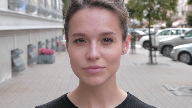
      </td>
      <td>
      <font size="96px">
      &#10145;</font>
      </td>
			<td>
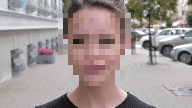
</td>
		</tr>
</table>

In [ ]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml -O /content/haarcascade_frontalface_default.xml

import cv2
from google.colab.patches import cv2_imshow
import numpy as np

def apply_mosaic_effect(face_roi, pixel_size=10):
    if face_roi.shape[0] == 0 or face_roi.shape[1] == 0:
        return face_roi
    h, w, _ = face_roi.shape
    small_h = max(1, h // pixel_size)
    small_w = max(1, w // pixel_size)
    if small_h == 0: small_h = 1
    if small_w == 0: small_w = 1
    downscaled = cv2.resize(face_roi, (small_w, small_h), interpolation=cv2.INTER_LINEAR)
    mosaiced_face = cv2.resize(downscaled, (w, h), interpolation=cv2.INTER_NEAREST)
    return mosaiced_face

output_video_path = '/content/HW5_Woman_Happy_blurred.mp4'
video_file_path = '/content/HW5_Woman_Happy.mp4'
video_capture = cv2.VideoCapture(video_file_path)
face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')

if not video_capture.isOpened():
    print("Error: Could not open video file.")
else:
    fps = int(video_capture.get(cv2.CAP_PROP_FPS))
    width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"Загружено видео с характеристиками: FPS={fps}, Width={width}, Height={height}")
    print(f"VideoWriter начинает запись в файл: {output_video_path}")

    video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0) # Reset video_capture to the beginning
    with tqdm(total=frame_count, desc="обработано ") as pbar:
      while video_capture.isOpened():
          ret, frame = video_capture.read()
          if not ret:
              break
          pbar.update(1)

          if False: cv2_imshow(cv2.resize(frame, None, fx=0.05, fy=0.05, interpolation=cv2.INTER_LINEAR))

          gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
          faces = face_cascade.detectMultiScale(gray, 1.1, 4)

          for (x, y, w, h) in faces:
              face_roi = frame[y:y+h, x:x+w]
              mosaiced_face = apply_mosaic_effect(face_roi, pixel_size=100)
              frame[y:y+h, x:x+w] = mosaiced_face
          video_writer.write(frame)

    video_capture.release()
    video_writer.release()
    cv2.destroyAllWindows()

    print(f"\nVideoWriter записал видео в файл {output_video_path}")

### Архитектура ML-системы блюра лиц

Слои системы:

```
Ingestion (REST upload / RTSP / S3 events)
        |
        v
Preprocessing (FFmpeg/OpenCV decode, resize, batching)
        |
        v
Inference (Triton GPU pool: YOLOv8-face / RetinaFace / SCRFD)
        |
        v
Postprocessing (NMS, фильтр по confidence, Gaussian blur / pixelation, трекинг)
        |
        v
Encoding & Output (JPEG/H.264, sync API или async S3 upload, audit log)
```

Сквозные слои: S3/MinIO для медиа, PostgreSQL для метаданных задач, Redis для очередей и кэша превью; Kafka или RabbitMQ для async-задач; k8s для оркестрации; Prometheus + Grafana + Loki для мониторинга; API Gateway с JWT для auth и RBAC.

Pipeline обучения детектора:

```
WIDER FACE / собственная разметка -> DVC stage аугментации (Albumentations)
        |
        v
Fine-tune YOLOv8-face (PyTorch, GPU pool) -> MLflow tracking
        |
        v
Eval на holdout: mAP@0.5, recall@small_faces, FPS
        |
        v
Если метрики >= baseline -> MLflow Model Registry (Staging)
        |
        v
Shadow deploy 10% -> канареечный rollout (Argo Rollouts) -> Production
```

Mermaid-диаграмма для рендера в GitHub/Obsidian/совместимых вьюверах:

```mermaid
flowchart LR
    subgraph Ingestion
      A1[REST upload]
      A2[RTSP stream]
      A3[S3 bucket event]
    end

    subgraph Realtime[Real-time path]
      B1[Frame decoder]
      B2[Face Detector<br/>Triton GPU]
      B3[Blur + encode]
      B4[WebRTC out]
    end

    subgraph Batch[Batch path]
      C1[Argo Workflow]
      C2[Distributed inference<br/>k8s job]
      C3[Output S3]
    end

    subgraph MLOps[MLOps plane]
      D1[(Feast<br/>feature store)]
      D2[(MLflow<br/>tracking + registry)]
      D3[DVC datasets]
      D4[Prometheus + Grafana]
      D5[Evidently<br/>drift]
    end

    A1 --> B1
    A2 --> B1
    A3 --> C1
    B1 --> B2 --> B3 --> B4
    C1 --> C2 --> C3
    B2 -.uses.-> D2
    C2 -.uses.-> D2
    D3 --> D2
    B3 -.metrics.-> D4
    C3 -.samples.-> D5
    D5 -.trigger retrain.-> D2
```

Ключевые SLO: p95 latency real-time < 100 ms (1 кадр 1080p), throughput около 30-40 FPS на 1 GPU T4, recall на лица > 30 px не ниже 0.95, precision (false-positive blur) не ниже 0.99, доступность API 99.9%.

Стек по слоям: API Gateway - Kong/Traefik; API - FastAPI; decoder - FFmpeg/OpenCV; inference - Triton/TorchServe; tracking - MLflow; datasets - DVC + S3/MinIO; orchestration - Argo Workflows + k8s; очереди - Kafka или Redis Streams; метаданные - Postgres; online features - Redis; monitoring - Prometheus/Grafana/Loki; drift - Evidently; CI/CD - GitHub Actions / Argo CD.

Полная архитектура с pipeline обучения, deployment strategy, SLO-таблицей и compliance-разделом - `docs/face_blur_architecture.md` в репо.


## 6. Финальные выводы

Что вышло в HW5:

1. Воспроизводимый ML-пайплайн на Wine. DVC версионирует данные (`data/raw/wine.csv.dvc`) и пайплайн из двух стадий (`dvc.yaml`: prepare и train). После `git clone` + `pip install` + `dvc pull` команда `dvc repro` даёт те же метрики, что зафиксированы в `metrics.json`.
2. MLflow tracking с локальным sqlite-backend. `src/train.py` логирует 6 параметров, 4 метрики (accuracy/f1/precision/recall macro), 2 артефакта (model.pkl и confusion_matrix.png) и сериализованную sklearn-модель через `mlflow.sklearn.log_model`.
3. Feature Store на PostgreSQL (а не на sqlite-template). В `src/feature_store/` Entity, FeatureView, FeatureService, registry в Postgres, online + offline store на одном backend; всё поднимается через `docker-compose.yml`.
4. Сравнение Jupyter и Marimo. В репо `notebooks/marimo_example.py` (рабочий Marimo-ноутбук) и `notebooks/analysis.md` (разбор по 5 критериям: hidden state, git, CI/CD, Colab-ограничения, MLOps-интеграция). Вывод - для production-pipeline Marimo предпочтительнее.
5. Архитектурная документация. `docs/face_blur_architecture.md` (7 разделов с mermaid-схемой и SLO-таблицей) и `docs/ml_system_readiness.md` (gap-анализ по 13 компонентам ML-системы).

Где осознанно отошёл от шаблона курса:

- Feast на postgres вместо local-template - ближе к production-сценарию, заодно показывает Docker-обвязку.
- В репо MLflow на локальном sqlite вместо курсового S3 - чтобы не зависеть от внешнего сервера. В этом ноутбуке курсовой S3 оставлен, как ожидает шаблон.
- Логика тренировки в отдельных `src/prepare.py` и `src/train.py`, а не в ноутбуке. DVC хеширует код стабильно (без перезаписи output-метаданных), MLflow-артефакт получается лёгким.

Чего не хватает до production-grade (см. `docs/ml_system_readiness.md`): inference service, model monitoring, drift detection, CI/CD, A/B и canary. Готовность системы оценил как 35-40%.
